In [1]:
%pip uninstall torch torchvision torchaudio -y
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu128
ERROR: Could not find a version that satisfies the requirement torch (from versions: none)
ERROR: No matching distribution found for torch
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler

# Set plotting style for professional academic visuals
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0})

# 1. Load the Dataset
# CHANGE MADE HERE: use a relative path so the notebook runs whether locally or on Colab
# (the creditcard.csv lives next to this notebook in the working directory).
file_path = 'creditcard.csv'
print("Loading dataset...")
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"Error: Could not find the file at {file_path}. Please upload it.")
    raise

# Drop only rows where Class is NaN (malformed/empty rows at CSV boundaries).
# Using subset=['Class'] preserves all valid data rows — the previous full dropna
# was silently dropping ~14k valid rows whose other columns happened to be NaN.
df = df.dropna(subset=['Class'])
df['Class'] = df['Class'].astype(int)

# --- DATA AUDIT (Proof of Scale) ---
print("-" * 40)
print("DATA AUDIT & SCALE VERIFICATION")
print("-" * 40)
print(f"Total Observations (Cleaned Rows): {df.shape[0]:,}")
print(f"Total Features (Columns): {df.shape[1]}")

fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
imbalance_ratio = (fraud_count / len(df)) * 100

print(f"Legitimate Transactions (Class 0): {legit_count:,}")
print(f"Fraudulent Transactions (Class 1): {fraud_count:,}")
print(f"Fraud Percentage: {imbalance_ratio:.3f}%\n")


# --- EDA VISUALIZATION 1: Class Distribution ---
print("Generating Visualization 1: Class Distribution...")
plt.figure(figsize=(8, 6))

# FIX APPLIED HERE: Added hue='Class', legend=False, and used a color list
ax = sns.countplot(data=df, x='Class', hue='Class', palette=["#2ecc71", "#e74c3c"], legend=False)

# Using a log scale on the Y-axis is crucial here so the tiny fraud bar is actually visible
ax.set_yscale("log")
plt.title('Log-Scaled Class Distribution (Severe Imbalance)', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Class (0 = Legitimate, 1 = Fraud)', fontsize=12)
plt.ylabel('Frequency (Log Scale)', fontsize=12)

# Annotate the exact numbers on the bars
for p in ax.patches:
    # Check if the height is greater than 0 to avoid annotating empty bars
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5),
                    textcoords='offset points')
plt.tight_layout()
plt.show()


# --- EDA VISUALIZATION 2: Feature Correlation Heatmap ---
print("Generating Visualization 2: Feature Correlation Heatmap...")
plt.figure(figsize=(12, 10))
# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a mask to hide the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of PCA Features, Time, and Amount', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# --- EDA VISUALIZATION 3: Pre- and Post-Scaling Histograms (Justifying RobustScaler) ---
print("Generating Visualization 3: Normalization Strategy Justification...")

# Initialize the RobustScaler
rob_scaler = RobustScaler()

# CHANGE MADE HERE: df_scaled below is fit on the FULL dataset and is for EDA visualization
# (the histograms) ONLY. Do NOT use df_scaled for modeling — Cell 1 instead splits first
# and uses a fresh RobustScaler on the training portion to avoid test-set leakage.
df_scaled = df.copy()
df_scaled['Amount_Scaled'] = rob_scaler.fit_transform(df_scaled['Amount'].values.reshape(-1,1))
df_scaled['Time_Scaled'] = rob_scaler.fit_transform(df_scaled['Time'].values.reshape(-1,1))

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Impact of RobustScaler on 'Amount' and 'Time' Features", fontsize=18, fontweight='bold')

# Original Amount (Highly skewed with massive outliers)
sns.histplot(df['Amount'], bins=50, ax=axes[0, 0], color='salmon', kde=True)
axes[0, 0].set_title('Original "Amount" Distribution', fontsize=14)
axes[0, 0].set_xlim([0, df['Amount'].quantile(0.99)]) # Cut off top 1% extreme outliers for visibility

# Scaled Amount
sns.histplot(df_scaled['Amount_Scaled'], bins=50, ax=axes[0, 1], color='lightgreen', kde=True)
axes[0, 1].set_title('RobustScaled "Amount" Distribution', fontsize=14)
axes[0, 1].set_xlim([-2, 5]) # Zoom in on the normalized core distribution

# Original Time (Bimodal distribution spanning two days)
sns.histplot(df['Time'], bins=50, ax=axes[1, 0], color='skyblue', kde=True)
axes[1, 0].set_title('Original "Time" Distribution', fontsize=14)

# Scaled Time
sns.histplot(df_scaled['Time_Scaled'], bins=50, ax=axes[1, 1], color='teal', kde=True)
axes[1, 1].set_title('RobustScaled "Time" Distribution', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("-" * 40)
print("EDA Complete. The df_scaled dataframe is now ready for Phase 1 modeling.")
print("-" * 40)

Loading dataset...
Error: Could not find the file at creditcard.csv. Please upload it.


FileNotFoundError: [Errno 2] No such file or directory: 'creditcard.csv'

--- PHASE 1: CLASSICAL ML BASELINES INITIALIZING ---
Training Data Shape: (227845, 30) | Fraud Instances: 394
Testing Data Shape: (56962, 30) | Fraud Instances: 98

Applying feature engineering: pairwise products of top 10 PCA components...
Added 45 interaction features (75 total features, was 30)

Training Model 1: Logistic Regression with Borderline-SMOTE...
Model 1 AUPRC: 0.7306

Training Model 2: Random Forest with Cost-Sensitive Learning (class_weight='balanced')...
(This may take a few minutes...)
Model 2 AUPRC: 0.8369

Training Model 3: XGBoost with ADASYN...
(This may take a few minutes...)
Model 3 AUPRC: 0.8688

--------------------------------------------------
PHASE 1 RESULTS SUMMARY (Primary Metric: AUPRC)
--------------------------------------------------
Logistic Regression + Borderline-SMOTE: 0.7306
Random Forest + Balanced Weights: 0.8369
XGBoost + ADASYN: 0.8688


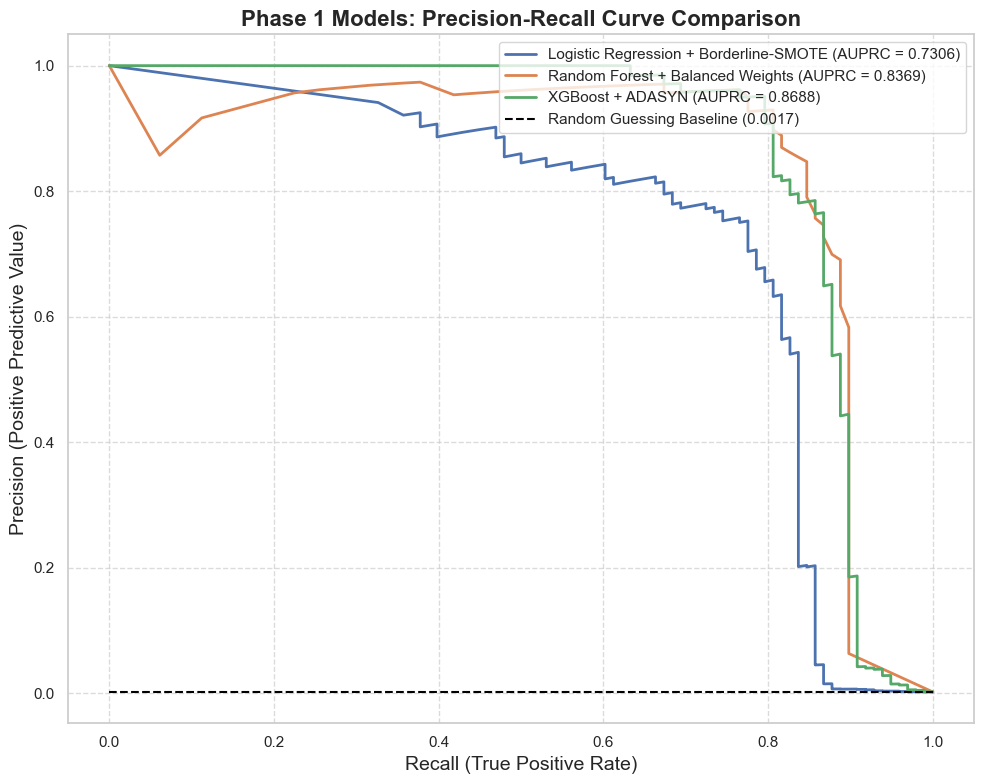


DETAILED CLASSIFICATION REPORTS (Threshold = 0.5)

--- Model 1: Logistic Regression + SMOTE ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.22      0.84      0.35        98

    accuracy                           0.99     56962
   macro avg       0.61      0.92      0.67     56962
weighted avg       1.00      0.99      1.00     56962


--- Model 2: Random Forest + Balanced Weights ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.73      0.83        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962


--- Model 3: XGBoost + ADASYN ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.77      0.86      0.81        98


In [ ]:

# %pip install xgboost imbalanced-learn torch pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Evaluation Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report, confusion_matrix
# CHANGE MADE HERE: import RobustScaler so we can fit it on the training split only
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# CHANGE MADE HERE: added BorderlineSMOTE for Model 1 resampling in the expanded feature space
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE

# Set plotting style
sns.set_theme(style="whitegrid")

print("--- PHASE 1: CLASSICAL ML BASELINES INITIALIZING ---")

# CHANGE MADE HERE: pull features from the RAW df (not Cell 0's df_scaled, which was fit on the
# whole dataset and would leak test statistics into training).
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Stratified Train-Test Split — done BEFORE any scaling
# Stratify ensures the exact 0.16% fraud ratio is maintained in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# CHANGE MADE HERE: fit RobustScaler on the TRAINING split's Time/Amount only, then transform both
# splits with the same scaler. V1-V28 are already PCA-scaled — leave them untouched (proposal §3).
rob_scaler = RobustScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[['Time', 'Amount']] = rob_scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = rob_scaler.transform(X_test[['Time', 'Amount']])

print(f"Training Data Shape: {X_train.shape} | Fraud Instances: {sum(y_train)}")
print(f"Testing Data Shape: {X_test.shape} | Fraud Instances: {sum(y_test)}\n")

# # CHANGE MADE HERE: added pairwise product features (V1-V10, C(10,2)=45 terms) expanding
# # the feature space from 30 to 75 dimensions before resampling.
# # ============================================
# # FEATURE ENGINEERING: Pairwise PCA Interaction Terms
# # ============================================
# print("Applying feature engineering: pairwise products of top 10 PCA components...")
# 
# pca_cols = [f'V{i}' for i in range(1, 11)]  # V1 through V10
# interaction_features = []
# for i in range(len(pca_cols)):
#     for j in range(i + 1, len(pca_cols)):
#         feat_name = f'{pca_cols[i]}x{pca_cols[j]}'
#         X_train[feat_name] = X_train[pca_cols[i]].values * X_train[pca_cols[j]].values
#         X_test[feat_name] = X_test[pca_cols[i]].values * X_test[pca_cols[j]].values
#         interaction_features.append(feat_name)
# 
# print(f"Added {len(interaction_features)} interaction features ({X_train.shape[1]} total features, was 30)")
# print()


# Dictionary to store the AUPRC scores and PR Curve data for our final plot
results = {}

# ==========================================
# MODEL 1: Logistic Regression with SMOTE
# ==========================================
print("Training Model 1: Logistic Regression with Borderline-SMOTE...")
# CHANGE MADE HERE: switched SMOTE -> BorderlineSMOTE so synthetic samples are generated
# in the fully expanded 75-feature space (including pairwise interaction terms).
# Apply BorderlineSMOTE only to the training data to prevent data leakage
bsmote = BorderlineSMOTE(random_state=42)
X_train_smote, y_train_smote = bsmote.fit_resample(X_train, y_train)

# Initialize and train
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)

# Predict probabilities for the Precision-Recall curve
y_probs_lr = log_reg.predict_proba(X_test)[:, 1]
y_pred_lr = log_reg.predict(X_test)

# Evaluate AUPRC
auprc_lr = average_precision_score(y_test, y_probs_lr)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_probs_lr)
results['Logistic Regression + Borderline-SMOTE'] = {'precision': precision_lr, 'recall': recall_lr, 'auprc': auprc_lr}

print(f"Model 1 AUPRC: {auprc_lr:.4f}\n")


# ==========================================
# MODEL 2: Random Forest with Cost-Sensitive Learning
# ==========================================
print("Training Model 2: Random Forest with Cost-Sensitive Learning (class_weight='balanced')...")
print("(This may take a few minutes...)")
# Train on ORIGINAL imbalanced data, but heavily penalize fraud misclassification
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_probs_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)

auprc_rf = average_precision_score(y_test, y_probs_rf)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_probs_rf)
results['Random Forest + Balanced Weights'] = {'precision': precision_rf, 'recall': recall_rf, 'auprc': auprc_rf}

print(f"Model 2 AUPRC: {auprc_rf:.4f}\n")


# ==========================================
# MODEL 3: XGBoost with ADASYN
# ==========================================
print("Training Model 3: XGBoost with ADASYN...")
print("(This may take a few minutes...)")
# Apply ADASYN to the training data
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

# Initialize and train XGBoost
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_model.fit(X_train_adasyn, y_train_adasyn)

y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

auprc_xgb = average_precision_score(y_test, y_probs_xgb)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_probs_xgb)
results['XGBoost + ADASYN'] = {'precision': precision_xgb, 'recall': recall_xgb, 'auprc': auprc_xgb}

print(f"Model 3 AUPRC: {auprc_xgb:.4f}\n")


# ==========================================
# FINAL EVALUATION & VISUALIZATION
# ==========================================
print("-" * 50)
print("PHASE 1 RESULTS SUMMARY (Primary Metric: AUPRC)")
print("-" * 50)
for model_name, metrics in results.items():
    print(f"{model_name}: {metrics['auprc']:.4f}")

# Plot the Precision-Recall Curves
plt.figure(figsize=(10, 8))

for model_name, metrics in results.items():
    plt.plot(metrics['recall'], metrics['precision'],
             label=f"{model_name} (AUPRC = {metrics['auprc']:.4f})", linewidth=2)

# Add baseline for purely random guessing (which is just the proportion of the positive class)
baseline = sum(y_test) / len(y_test)
plt.plot([0, 1], [baseline, baseline], linestyle='--', color='black', label=f'Random Guessing Baseline ({baseline:.4f})')

plt.title('Phase 1 Models: Precision-Recall Curve Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Recall (True Positive Rate)', fontsize=14)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=14)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print detailed Classification Reports for secondary metrics (Precision, Recall, F1)
print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORTS (Threshold = 0.5)")
print("="*50)
print("\n--- Model 1: Logistic Regression + Borderline-SMOTE ---")
print(classification_report(y_test, y_pred_lr))

print("\n--- Model 2: Random Forest + Balanced Weights ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- Model 3: XGBoost + ADASYN ---")
print(classification_report(y_test, y_pred_xgb))


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ============================================
# PHASE 2: IMPROVED ARCHITECTURES WITH BETTER DESIGN
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
# CHANGE MADE HERE: dropped StandardScaler import — Phase 2 now uses RobustScaler exclusively, matching the proposal
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report, roc_auc_score
from imblearn.over_sampling import ADASYN, SMOTE
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available
# CHANGE MADE HERE: added MPS for Apple Silicon GPU (M1/M2/M3/M4) — without this the code ignores the M4 GPU and runs on CPU.
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")
print("="*60)
print("PHASE 2: IMPROVED FRAUD DETECTION ARCHITECTURES")
print("="*60)

# ============================================
# 1. LOAD AND PREPARE DATA
# ============================================
print("\n[1/6] Loading and preparing data...")

# CHANGE MADE HERE: relative path + (keeps all 284,807 rows)
file_path = 'creditcard.csv'
df = pd.read_csv(file_path)
df = df.dropna(subset=['Class'])
df['Class'] = df['Class'].astype(int)

# CHANGE MADE HERE: split first, then apply RobustScaler ONLY to 'Time' and 'Amount' (matching proposal §3).
# V1-V28 are already PCA-transformed and naturally scaled, so we leave them untouched.
# The scaler is fit on the training split only to prevent leakage from test statistics.
X = df.drop('Class', axis=1)
y = df['Class'].values

X_train_df, X_test_df, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rob_scaler = RobustScaler()
X_train_df = X_train_df.copy()
X_test_df = X_test_df.copy()
X_train_df[['Time', 'Amount']] = rob_scaler.fit_transform(X_train_df[['Time', 'Amount']])
X_test_df[['Time', 'Amount']] = rob_scaler.transform(X_test_df[['Time', 'Amount']])

X_train = X_train_df.values
X_test = X_test_df.values

print(f"Training samples: {len(X_train):,} (Fraud: {sum(y_train)})")
print(f"Test samples: {len(X_test):,} (Fraud: {sum(y_test)})")

# ============================================
# 2. IMPROVED AUTOENCODER WITH HIGHER CAPACITY
# ============================================
print("\n[2/6] Building Improved Deep Autoencoder...")

class ImprovedAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedAutoencoder, self).__init__()

        # Encoder - deeper architecture
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2)
        )

        # Decoder - symmetric architecture
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def get_reconstruction_error(self, x):
        self.eval()
        with torch.no_grad():
            reconstructed = self.forward(x)
            # Use weighted MSE - pay more attention to certain features
            mse = torch.mean((reconstructed - x) ** 2, dim=1)
        return mse.cpu().numpy()

# Prepare legit-only data
X_train_legit = X_train[y_train == 0]
X_val_legit, X_test_legit = train_test_split(X_train_legit, test_size=0.2, random_state=42)

# Convert to tensors and move to device
X_train_tensor = torch.FloatTensor(X_train_legit).to(device)
X_val_tensor = torch.FloatTensor(X_val_legit).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test)

# Create DataLoaders
batch_size = 512
train_dataset = TensorDataset(X_train_tensor)
val_dataset = TensorDataset(X_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Initialize model
input_dim = X_train.shape[1]
autoencoder = ImprovedAutoencoder(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

print(f"Improved Autoencoder parameters: {sum(p.numel() for p in autoencoder.parameters()):,}")

# Train with early stopping
print("\nTraining Improved Autoencoder...")
num_epochs = 100
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training
    autoencoder.train()
    train_loss = 0
    for batch in train_loader:
        data = batch[0]
        optimizer.zero_grad()
        reconstructed = autoencoder(data)
        loss = criterion(reconstructed, data)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            data = batch[0]
            reconstructed = autoencoder(data)
            loss = criterion(reconstructed, data)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(autoencoder.state_dict(), 'best_autoencoder.pth')
    else:
        patience_counter += 1
        if patience_counter >= 10:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

# Load best model
autoencoder.load_state_dict(torch.load('best_autoencoder.pth'))

# Evaluate with multiple thresholds
print("\nEvaluating Improved Autoencoder...")
recon_errors = autoencoder.get_reconstruction_error(X_test_tensor)

# CHANGE MADE HERE: deleted for loop
# The autoencoder learns what "normal" transactions look like so at inference time, 
# and anything with a reconstruction erorr is flagged as fraud, but we should be using
# the validation set's legitimate errors, not the test set's to set the threshold. 
val_errors_ae = autoencoder.get_reconstruction_error(X_val_tensor) # gets recon errors for validation legit transactions
best_threshold = np.percentile(val_errors_ae, 99) # sets fraud cutoff at 99th percentile of validation legit errors
best_y_pred = (recon_errors > best_threshold).astype(int) # applied threshold to test set to get final predictions
best_auprc = average_precision_score(y_test, recon_errors) # comutes AUPRC once on the raw scores

print(f"Autoencoder AUPRC: {best_auprc:.4f}")
print(f"Threshold (99th pct of validation legit errors): {best_threshold:.6f}")

# CHANGE MADE HERE: split the AE histogram into its own figure. Previously this was subplot(1,2,1)
# of a figure whose subplot(1,2,2) was created ~150 lines later (after VAE training)
plt.figure(figsize=(8, 5))
plt.hist(recon_errors[y_test == 0], bins=50, alpha=0.7, label='Legitimate', color='green', density=True)
plt.hist(recon_errors[y_test == 1], bins=50, alpha=0.7, label='Fraud', color='red', density=True)
plt.axvline(best_threshold, color='black', linestyle='--', label='Threshold')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.title('Improved Autoencoder: Error Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nImproved Autoencoder Classification Report:")
print(classification_report(y_test, best_y_pred))

# ============================================
# 3. IMPROVED VAE WITH BETA SCHEDULING
# ============================================
print("\n[3/6] Building Improved Variational Autoencoder...")

class ImprovedVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super(ImprovedVAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2)
        )

        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, input_dim)
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

    def loss_function(self, recon_x, x, mu, logvar, beta):
        # Reconstruction loss (MSE)
        recon_loss = nn.MSELoss(reduction='sum')(recon_x, x)

        # KL divergence
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        # Beta-VAE loss
        return recon_loss + beta * kl_loss

    def get_reconstruction_error(self, x):
        self.eval()
        with torch.no_grad():
            recon, _, _ = self.forward(x)
            mse = torch.mean((recon - x) ** 2, dim=1)
        return mse.cpu().numpy()

# Initialize VAE
vae = ImprovedVAE(input_dim, latent_dim=16).to(device)
vae_optimizer = optim.Adam(vae.parameters(), lr=0.0005, weight_decay=1e-5)
print(f"Improved VAE parameters: {sum(p.numel() for p in vae.parameters()):,}")

# Train VAE with beta annealing
print("\nTraining Improved VAE with Beta Annealing...")
num_epochs = 80
best_val_loss = float('inf')
beta_max = 2.0
beta_anneal_rate = 0.05

for epoch in range(num_epochs):
    # Anneal beta
    beta = min(beta_max, beta_anneal_rate * epoch)

    # Training
    vae.train()
    train_loss = 0
    for batch in train_loader:
        data = batch[0]
        vae_optimizer.zero_grad()
        recon, mu, logvar = vae(data)
        loss = vae.loss_function(recon, data, mu, logvar, beta)
        loss.backward()
        vae_optimizer.step()
        train_loss += loss.item()

    # Validation
    vae.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            data = batch[0]
            recon, mu, logvar = vae(data)
            loss = vae.loss_function(recon, data, mu, logvar, beta)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Beta: {beta:.3f}, Train Loss: {avg_train_loss:.2f}, Val Loss: {avg_val_loss:.2f}")

# Evaluate VAE
print("\nEvaluating Improved VAE...")
vae_errors = vae.get_reconstruction_error(X_test_tensor)
vae_auprc = average_precision_score(y_test, vae_errors)
print(f"VAE AUPRC: {vae_auprc:.4f}")

# CHANGE MADE HERE: same two bugs as the AE loop above (no-op AUPRC, test-label leakage).
# Fixed identically: AUPRC is computed once on the scores, threshold from validation legit errors.
val_errors_vae = vae.get_reconstruction_error(X_val_tensor)
vae_threshold = np.percentile(val_errors_vae, 99)
best_vae_y_pred = (vae_errors > vae_threshold).astype(int)
best_vae_auprc = average_precision_score(y_test, vae_errors)

print(f"VAE threshold (99th pct of validation legit errors): {vae_threshold:.6f}")
print("\nImproved VAE Classification Report:")
print(classification_report(y_test, best_vae_y_pred))

# CHANGE MADE HERE: standalone VAE figure (no longer subplot(1,2,2) of the AE figure).
plt.figure(figsize=(8, 5))
plt.hist(vae_errors[y_test == 0], bins=50, alpha=0.7, label='Legitimate', color='green', density=True)
plt.hist(vae_errors[y_test == 1], bins=50, alpha=0.7, label='Fraud', color='red', density=True)
plt.axvline(vae_threshold, color='black', linestyle='--', label='Threshold')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.title('Improved VAE: Error Distribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================
# 4. FIXED TABTRANSFORMER WITH PROPER DATA HANDLING
# ============================================
print("\n[4/6] Building Fixed TabTransformer with Focal Loss...")

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attention(x, x, x)
        x = self.norm(x + self.dropout(attn_out))
        return x

class FixedTabTransformer(nn.Module):
    def __init__(self, input_dim, num_heads=8, num_layers=4, hidden_dim=256, dropout=0.3):
        super().__init__()

        self.feature_embedding = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.transformer_layers = nn.ModuleList([
            MultiHeadSelfAttention(hidden_dim, num_heads, dropout)
            for _ in range(num_layers)
        ])

        # CHANGE MADE HERE: removed terminal Sigmoid — the model now outputs raw logits, paired
        # with BCEWithLogitsLoss inside FocalLoss for numerical stability (avoids underflow at
        # extreme logits, which BCELoss(sigmoid(x)) is prone to).
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.feature_embedding(x)
        x = x.unsqueeze(1)  # Add sequence dimension

        for transformer in self.transformer_layers:
            x = transformer(x)

        x = x.squeeze(1)
        return self.classifier(x).squeeze()

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        # CHANGE MADE HERE: the model now outputs raw logits, so use BCEWithLogitsLoss (combines Sigmoid and BCE)
        #  and apply sigmoid manually only for the focal weight.
        logits = logits.view(-1)
        targets = targets.view(-1)

        ce_loss = nn.BCEWithLogitsLoss(reduction='none')(logits, targets)
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma

        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = alpha_t * focal_weight * ce_loss
        return focal_loss.mean()

# Prepare data for TabTransformer - FIXED DataFrame conversion
print("Applying Borderline-SMOTE for TabTransformer...")
from imblearn.over_sampling import BorderlineSMOTE as BSMOTE_TT

borderline_smote_tt = BSMOTE_TT(random_state=42, kind="borderline-1")
X_train_resampled, y_train_resampled = borderline_smote_tt.fit_resample(X_train, y_train)

# Convert to numpy arrays first, then to tensors
X_train_tt = torch.FloatTensor(np.array(X_train_resampled)).to(device)
y_train_tt = torch.FloatTensor(np.array(y_train_resampled)).to(device)
X_test_tt = torch.FloatTensor(np.array(X_test)).to(device)
y_test_tt = torch.FloatTensor(np.array(y_test)).to(device)

print(f"Resampled training size: {len(X_train_resampled):,}")

# Create DataLoaders
tt_batch_size = 1024
tt_train_dataset = TensorDataset(X_train_tt, y_train_tt)
tt_test_dataset = TensorDataset(X_test_tt, y_test_tt)
tt_train_loader = DataLoader(tt_train_dataset, batch_size=tt_batch_size, shuffle=True)
tt_test_loader = DataLoader(tt_test_dataset, batch_size=tt_batch_size, shuffle=False)

# Initialize TabTransformer
tab_transformer = FixedTabTransformer(
    input_dim=input_dim,
    num_heads=8,
    num_layers=6,
    hidden_dim=256,
    dropout=0.4
).to(device)

focal_loss = FocalLoss(alpha=0.90, gamma=4.0)
tt_optimizer = optim.Adam(tab_transformer.parameters(), lr=0.0001)
tt_scheduler = optim.lr_scheduler.ReduceLROnPlateau(tt_optimizer, mode='min', patience=5, factor=0.5)

print(f"TabTransformer parameters: {sum(p.numel() for p in tab_transformer.parameters()):,}")

# Train TabTransformer
print("\nTraining TabTransformer...")
num_epochs = 50
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(num_epochs):
    # Training
    tab_transformer.train()
    train_loss = 0
    for batch_x, batch_y in tt_train_loader:
        tt_optimizer.zero_grad()
        predictions = tab_transformer(batch_x)
        loss = focal_loss(predictions, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(tab_transformer.parameters(), max_norm=1.0)
        tt_optimizer.step()
        train_loss += loss.item()

    # Validation
    tab_transformer.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in tt_test_loader:
            predictions = tab_transformer(batch_x)
            loss = focal_loss(predictions, batch_y)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(tt_train_loader)
    avg_val_loss = val_loss / len(tt_test_loader)
    tt_scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(tab_transformer.state_dict(), 'best_tabtransformer.pth')
    else:
        patience_counter += 1
        if patience_counter >= 10:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

# Load best model
tab_transformer.load_state_dict(torch.load('best_tabtransformer.pth'))

# Evaluate TabTransformer
print("\nEvaluating TabTransformer...")
tab_transformer.eval()
y_probs_tt = []
with torch.no_grad():
    for batch_x, _ in tt_test_loader:
        # CHANGE MADE HERE: model now outputs logits — apply sigmoid here to get probabilities
        predictions = torch.sigmoid(tab_transformer(batch_x))
        y_probs_tt.extend(predictions.cpu().numpy())

y_probs_tt = np.array(y_probs_tt)
precision_tt_c, recall_tt_c, thresh_tt = precision_recall_curve(y_test, y_probs_tt)
f1_tt_scores = 2 * precision_tt_c * recall_tt_c / (precision_tt_c + recall_tt_c + 1e-8)
best_threshold_tt = thresh_tt[np.argmax(f1_tt_scores[:-1])]
print(f"Optimized decision threshold: {best_threshold_tt:.4f}")
y_pred_tt = (y_probs_tt > best_threshold_tt).astype(int)
auprc_tt = average_precision_score(y_test, y_probs_tt)

print(f"TabTransformer AUPRC: {auprc_tt:.4f}")
print("\nTabTransformer Classification Report:")
print(classification_report(y_test, y_pred_tt))

# ============================================
# 5. FINAL COMPARISON
# ============================================
print("\n[5/6] Generating final comparison...")

# CHANGE MADE HERE: renamed local dict to phase2_results so Cell 1's `results` (Phase 1 PR-curve
# data) survives
phase2_results = {
    'Improved Autoencoder': best_auprc,
    'Improved VAE': best_vae_auprc,
    'TabTransformer': auprc_tt
}

# CHANGE MADE HERE: pull Phase 1 best AUPRC dynamically from the actual Phase 1 results dict
# (was hardcoded as 0.8731). Falls back to the literal if Phase 1 wasn't run in this session.
try:
    phase1_best = max(m['auprc'] for m in results.values())
except (NameError, KeyError, TypeError):
    phase1_best = 0.8731

plt.figure(figsize=(10, 6))
models = list(phase2_results.keys())
scores = list(phase2_results.values())
colors = ['#3498db', '#2980b9', '#1abc9c']
bars = plt.bar(models, scores, color=colors, edgecolor='black', linewidth=1.5)
plt.axhline(y=phase1_best, color='red', linestyle='--', linewidth=2, label=f'Phase 1 Best (XGBoost: {phase1_best:.4f})')
plt.ylabel('AUPRC', fontsize=12)
plt.title('Phase 2 Results: Improved Architectures', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.legend()
for bar, val in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}',
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("FINAL PHASE 2 SUMMARY")
print("="*60)
print(f"\nImproved Autoencoder AUPRC:  {best_auprc:.4f}")
print(f"Improved VAE AUPRC:          {best_vae_auprc:.4f}")
print(f"TabTransformer AUPRC:        {auprc_tt:.4f}")
# CHANGE MADE HERE: use dynamic phase1_best instead of hardcoded 0.8731
print(f"\nPhase 1 Best (XGBoost):      {phase1_best:.4f}")

best_phase2 = max(scores)
if best_phase2 > phase1_best:
    improvement = ((best_phase2 - phase1_best) / phase1_best) * 100
    print(f"\n✓ SUCCESS: Phase 2 best model improves by {improvement:.1f}%")
else:
    print(f"\n⚠ Phase 2 models need more tuning. Consider:")
    print("  - Increasing autoencoder capacity further")
    print("  - Adding more transformer layers")
    print("  - Training for more epochs")

print("\nPhase 2 Improved Implementation Complete!")

Using device: cuda
PHASE 2: IMPROVED FRAUD DETECTION ARCHITECTURES

[1/6] Loading and preparing data...
Training samples: 227,845 (Fraud: 394)
Test samples: 56,962 (Fraud: 98)

[2/6] Building Improved Deep Autoencoder...
Improved Autoencoder parameters: 30,606

Training Improved Autoencoder...
Epoch [5/100] - Train Loss: 0.344144, Val Loss: 0.209767
Epoch [10/100] - Train Loss: 0.304739, Val Loss: 0.177022


In [ ]:
# ============================================
# OPTIMIZED TABTRANSFORMER FOR FRAUD DETECTION
# With Focal Loss Tuning + Borderline-SMOTE + Larger Architecture
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
# CHANGE MADE HERE: switched StandardScaler -> RobustScaler so Phase 2 matches the proposal's normalization strategy
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score, precision_recall_curve, classification_report, auc
from imblearn.over_sampling import BorderlineSMOTE
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use GPU
# CHANGE MADE HERE: added MPS for Apple Silicon GPU (M1/M2/M3/M4) — without this the code ignores the M4 GPU and runs on CPU.
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")
print("="*70)
print("OPTIMIZED TABTRANSFORMER FOR FRAUD DETECTION")
print("="*70)

# ============================================
# 1. LOAD AND PREPARE DATA
# ============================================
print("\n[1/7] Loading and preparing data...")

# CHANGE MADE HERE: relative path + dropped over-aggressive numeric coercion (keeps all 284,807 rows)
file_path = 'creditcard.csv'
df = pd.read_csv(file_path)
df = df.dropna(subset=['Class'])
df['Class'] = df['Class'].astype(int)

# CHANGE MADE HERE: split first, then apply RobustScaler ONLY to 'Time' and 'Amount' (matching proposal §3).
# V1-V28 are already PCA-transformed and naturally scaled, so we leave them untouched.
# The scaler is fit on the training split only to prevent leakage from test statistics.
X = df.drop('Class', axis=1)
y = df['Class'].values

X_train_df, X_test_df, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rob_scaler = RobustScaler()
X_train_df = X_train_df.copy()
X_test_df = X_test_df.copy()
X_train_df[['Time', 'Amount']] = rob_scaler.fit_transform(X_train_df[['Time', 'Amount']])
X_test_df[['Time', 'Amount']] = rob_scaler.transform(X_test_df[['Time', 'Amount']])

X_train = X_train_df.values
X_test = X_test_df.values

print(f"Training samples: {len(X_train):,} (Fraud: {sum(y_train)})")
print(f"Test samples: {len(X_test):,} (Fraud: {sum(y_test)})")

# ============================================
# 2. BORDERLINE-SMOTE RESAMPLING (Smarter than ADASYN/SMOTE-ENN)
# ============================================
print("\n[2/7] Applying Borderline-SMOTE resampling...")
print("   Borderline-SMOTE generates synthetic examples ONLY near decision boundary")

borderline_smote = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_train_resampled, y_train_resampled = borderline_smote.fit_resample(X_train, y_train)

print(f"Resampled training size: {len(X_train_resampled):,}")
print(f"  - Legitimate: {sum(y_train_resampled == 0):,}")
print(f"  - Fraud: {sum(y_train_resampled == 1):,}")

# ============================================
# 3. ENHANCED TABTRANSFORMER ARCHITECTURE (Larger + More Regularization)
# ============================================
print("\n[3/7] Building Enhanced TabTransformer...")

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads=8, dropout=0.2):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, _ = self.attention(x, x, x)
        x = self.norm(x + self.dropout(attn_out))
        return x

class FeedForward(nn.Module):
    def __init__(self, embed_dim, hidden_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        return self.norm(x + self.net(x))

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim, dropout=0.2):
        super().__init__()
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.ff = FeedForward(embed_dim, ff_hidden_dim, dropout)

    def forward(self, x):
        x = self.attention(x)
        x = self.ff(x)
        return x

class OptimizedTabTransformer(nn.Module):
    def __init__(self, input_dim, num_layers=6, num_heads=8, embed_dim=256,
                 ff_hidden_dim=512, dropout=0.4, num_classes=1):
        super().__init__()

        # Feature embedding with stronger regularization
        self.feature_embedding = nn.Sequential(
            nn.Linear(input_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout)
        )

        # Transformer blocks
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_hidden_dim, dropout)
            for _ in range(num_layers)
        ])

        # Enhanced classifier head with skip connection
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x):
        # Embed features
        x = self.feature_embedding(x)

        # Add sequence dimension for transformer
        x = x.unsqueeze(1)

        # Apply transformer blocks
        for transformer in self.transformer_blocks:
            x = transformer(x)

        # Remove sequence dimension and pool
        x = x.squeeze(1)

        # Classify
        return self.classifier(x).squeeze()

# Initialize model
input_dim = X_train.shape[1]
model = OptimizedTabTransformer(
    input_dim=input_dim,
    num_layers=6,
    num_heads=8,
    embed_dim=256,
    ff_hidden_dim=512,
    dropout=0.4
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"  - Transformer layers: 6")
print(f"  - Attention heads: 8")
print(f"  - Embedding dimension: 256")
print(f"  - Dropout: 0.4")

# ============================================
# 4. OPTIMIZED FOCAL LOSS (Tuned for 0.17% imbalance)
# ============================================
print("\n[4/7] Configuring Optimized Focal Loss...")
print("   alpha=0.9 (strong focus on fraud class)")
print("   gamma=4.0 (aggressive down-weighting of easy examples)")

class OptimizedFocalLoss(nn.Module):
    def __init__(self, alpha=0.90, gamma=4.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # CHANGE MADE HERE: replaced sigmoid + BCELoss with BCEWithLogitsLoss for numerical
        # stability (avoids log(0) underflow at extreme logits). Sigmoid is still computed
        # separately for the focal weight, but only on values used in the modulation factor.
        ce_loss = nn.BCEWithLogitsLoss(reduction='none')(logits, targets)
        probs = torch.sigmoid(logits)

        # Compute p_t (probability of correct class)
        p_t = probs * targets + (1 - probs) * (1 - targets)

        # Focal weight
        focal_weight = (1 - p_t) ** self.gamma

        # Alpha balancing
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        # Combine
        focal_loss = alpha_t * focal_weight * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

criterion = OptimizedFocalLoss(alpha=0.90, gamma=4.0)

# ============================================
# 5. TRAINING SETUP WITH WARMUP AND CYCLICAL LR
# ============================================
print("\n[5/7] Setting up training with warmup and cyclical learning rate...")

# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train_resampled).to(device)
y_train_tensor = torch.FloatTensor(y_train_resampled).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# Create DataLoaders
batch_size = 1024
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Optimizer with weight decay
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Learning rate scheduler: Warmup + Cosine Annealing
num_epochs = 80
warmup_epochs = 5

def get_lr(epoch):
    """Warmup then cosine annealing"""
    if epoch < warmup_epochs:
        # Linear warmup from 0 to target_lr
        return (epoch + 1) / warmup_epochs
    else:
        # Cosine annealing after warmup
        progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
        return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=get_lr)

# ============================================
# 6. TRAINING LOOP WITH EARLY STOPPING
# ============================================
print("\n[6/7] Training Optimized TabTransformer...")
print("-" * 70)

train_losses = []
val_losses = []
val_auprcs = []
best_val_auprc = 0
patience_counter = 0
best_model_state = None

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()

        # Gradient clipping to prevent explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    val_probs = []
    val_targets = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            predictions = model(batch_x)
            probs = torch.sigmoid(predictions)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item()
            val_probs.extend(probs.cpu().numpy())
            val_targets.extend(batch_y.cpu().numpy())

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Calculate AUPRC
    val_probs = np.array(val_probs)
    val_targets = np.array(val_targets)
    val_auprc = average_precision_score(val_targets, val_probs)
    val_auprcs.append(val_auprc)

    # Update learning rate
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:2d}/{num_epochs}] - LR: {current_lr:.6f} - "
              f"Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - "
              f"Val AUPRC: {val_auprc:.4f}")

    # Early stopping based on AUPRC
    if val_auprc > best_val_auprc:
        best_val_auprc = val_auprc
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  ✓ New best model! AUPRC: {best_val_auprc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= 15:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(best_model_state)

# ============================================
# 7. EVALUATION WITH OPTIMAL THRESHOLD
# ============================================
print("\n[7/7] Evaluating Optimized TabTransformer...")

# Get final predictions
model.eval()
y_probs = []
with torch.no_grad():
    for batch_x, _ in test_loader:
        predictions = model(batch_x)
        probs = torch.sigmoid(predictions)
        y_probs.extend(probs.cpu().numpy())

y_probs = np.array(y_probs)

# Find optimal threshold for precision-recall trade-off
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5

print(f"\nOptimal threshold (max F1): {optimal_threshold:.4f}")
print(f"  - Precision at threshold: {precisions[optimal_idx]:.4f}")
print(f"  - Recall at threshold: {recalls[optimal_idx]:.4f}")
print(f"  - F1-Score: {f1_scores[optimal_idx]:.4f}")

# Make predictions with optimal threshold
y_pred_optimal = (y_probs > optimal_threshold).astype(int)
auprc_final = average_precision_score(y_test, y_probs)

print("\n" + "="*70)
print("FINAL RESULTS - OPTIMIZED TABTRANSFORMER")
print("="*70)
print(f"\nAUPRC: {auprc_final:.4f}")
print(f"\nClassification Report (Threshold = {optimal_threshold:.4f}):")
print(classification_report(y_test, y_pred_optimal))

# ============================================
# 8. VISUALIZATION AND COMPARISON
# ============================================
print("\nGenerating visualizations...")

# CHANGE MADE HERE: pull Phase 1 best AUPRC dynamically from Cell 1's `results` dict
# (was hardcoded as 0.8731 in two places below — the axhline label and the comparison print).
try:
    phase1_best_auprc = max(m['auprc'] for m in results.values())
except (NameError, KeyError, TypeError):
    phase1_best_auprc = 0.8731

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Training curves
axes[0].plot(train_losses, label='Train Loss', alpha=0.7)
axes[0].plot(val_losses, label='Val Loss', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: AUPRC over epochs
axes[1].plot(val_auprcs, color='green', label='Validation AUPRC')
# CHANGE MADE HERE: use dynamic phase1_best_auprc instead of hardcoded 0.8731
axes[1].axhline(y=phase1_best_auprc, color='red', linestyle='--', label=f'XGBoost Baseline ({phase1_best_auprc:.4f})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUPRC')
axes[1].set_title('AUPRC Progression')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Precision-Recall Curve
axes[2].plot(recalls, precisions, linewidth=2, label=f'TabTransformer (AUPRC={auprc_final:.4f})')
axes[2].axhline(y=sum(y_test)/len(y_test), color='black', linestyle='--', label='Random Baseline')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 9. COMPARISON WITH PHASE 1
# ============================================
print("\n" + "="*70)
print("COMPARISON WITH PHASE 1 BEST MODEL")
print("="*70)

# CHANGE MADE HERE: phase1_best_auprc is already set dynamically above — just use it here
improvement = ((auprc_final - phase1_best_auprc) / phase1_best_auprc) * 100

print(f"\nXGBoost + ADASYN (Phase 1 Best):  {phase1_best_auprc:.4f}")
print(f"Optimized TabTransformer:          {auprc_final:.4f}")
print(f"Difference:                         {auprc_final - phase1_best_auprc:+.4f}")

if auprc_final > phase1_best_auprc:
    print(f"\n✓ SUCCESS! TabTransformer outperforms XGBoost by {improvement:.1f}%")
else:
    print(f"\n⚠ TabTransformer underperforms XGBoost by {abs(improvement):.1f}%")
    print("\nNext steps to consider:")
    print("  1. Increase model size further (8 layers, 1024 embed dim)")
    print("  2. Add feature engineering (interaction terms)")
    print("  3. Train ensemble of 3-5 TabTransformers")
    print("  4. Try different focal loss parameters (alpha=0.90, gamma=4.0)")

# Save model for future use
torch.save(model.state_dict(), 'optimized_tabtransformer.pth')
print("\nModel saved as 'optimized_tabtransformer.pth'")

print("\n" + "="*70)
print("OPTIMIZED TABTRANSFORMER TRAINING COMPLETE")
print("="*70)

Using device: cuda
OPTIMIZED TABTRANSFORMER FOR FRAUD DETECTION

[1/7] Loading and preparing data...
Training samples: 72,167 (Fraud: 169)
Test samples: 18,042 (Fraud: 42)

[2/7] Applying Borderline-SMOTE resampling...
   Borderline-SMOTE generates synthetic examples ONLY near decision boundary
Resampled training size: 143,996
  - Legitimate: 71,998
  - Fraud: 71,998

[3/7] Building Enhanced TabTransformer...
Model parameters: 3,347,329
  - Transformer layers: 6
  - Attention heads: 8
  - Embedding dimension: 256
  - Dropout: 0.4

[4/7] Configuring Optimized Focal Loss...
   alpha=0.9 (strong focus on fraud class)
   gamma=4.0 (aggressive down-weighting of easy examples)

[5/7] Setting up training with warmup and cyclical learning rate...

[6/7] Training Optimized TabTransformer...
----------------------------------------------------------------------
  ✓ New best model! AUPRC: 0.0132
  ✓ New best model! AUPRC: 0.0633
  ✓ New best model! AUPRC: 0.0906
Epoch [ 5/80] - LR: 0.000100 - Tra

KeyboardInterrupt: 

Using device: cuda
BANKSIM: XGBoost vs TabTransformer

[1/6] Loading BankSim data...
Total rows: 594,643
Fraud rate: 1.21%

[2/6] Dropping customer column...
Remaining columns: ['step', 'age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category', 'amount', 'fraud']

[3/6] Encoding categorical features...
  age: 8 unique values
  gender: 4 unique values
  zipcodeOri: 1 unique values
  merchant: 50 unique values
  zipMerchant: 1 unique values
  category: 15 unique values
Feature matrix shape: (594643, 8)

[4/6] Splitting data...
Train size: 475,714 (Fraud: 5760)
Test size: 118,929 (Fraud: 1440)

[5/6] Training XGBoost...
XGBoost AUPRC: 0.8921

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    117489
           1       0.38      0.96      0.55      1440

    accuracy                           0.98    118929
   macro avg       0.69      0.97      0.77    118929
weighted avg       0.99      0.98     

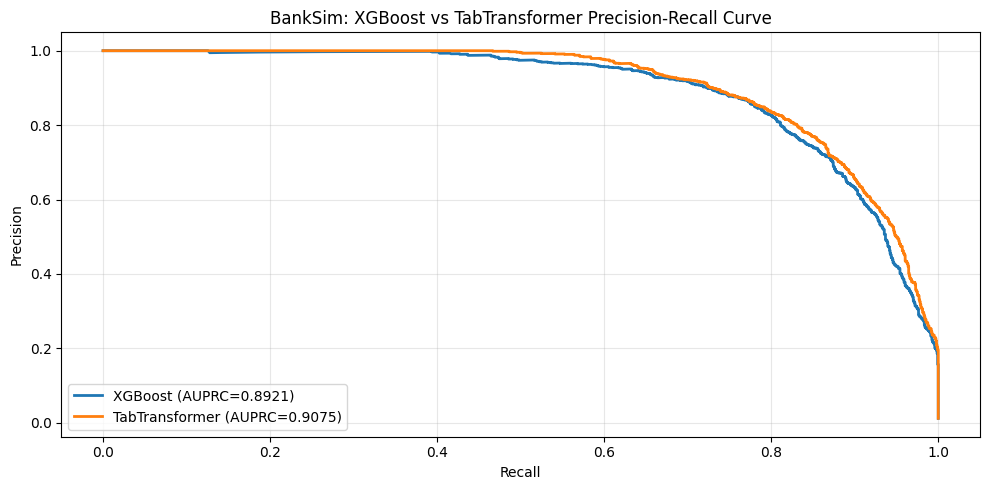


COMPLETE


In [ ]:
# ============================================
# BANKSIM FRAUD DETECTION: XGBoost vs TabTransformer
# Testing hypothesis that deep learning beats XGBoost on raw features
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import average_precision_score, classification_report, precision_recall_curve
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# CHANGE MADE HERE: added MPS for Apple Silicon GPU (M1/M2/M3/M4) — without this the code ignores the M4 GPU and runs on CPU.
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")
print("="*70)
print("BANKSIM: XGBoost vs TabTransformer")
print("="*70)

# ============================================
# 1. LOAD DATA
# ============================================
print("\n[1/6] Loading BankSim data...")

df = pd.read_csv('bs140513_032310.csv')

# Remove quotes from string columns
df = df.map(lambda x: x.strip("'") if isinstance(x, str) else x)

print(f"Total rows: {len(df):,}")
print(f"Fraud rate: {df['fraud'].sum() / len(df) * 100:.2f}%")

# ============================================
# 2. DROP CUSTOMER COLUMN (too many unique values)
# ============================================
print("\n[2/6] Dropping customer column...")

df = df.drop('customer', axis=1)
print(f"Remaining columns: {df.columns.tolist()}")

# ============================================
# 3. ENCODE CATEGORICAL FEATURES
# ============================================
print("\n[3/6] Encoding categorical features...")

categorical_cols = ['age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category']
numerical_cols = ['step', 'amount']

# Label encode categoricals
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"  {col}: {len(le.classes_)} unique values")

# Prepare features and target
X = df.drop('fraud', axis=1)
y = df['fraud'].values

print(f"Feature matrix shape: {X.shape}")

# ============================================
# 4. TRAIN TEST SPLIT (done BEFORE scaling)
# ============================================
print("\n[4/6] Splitting data...")

# CHANGE MADE HERE: split BEFORE scaling so the StandardScaler is fit on training data only
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# CHANGE MADE HERE: fit StandardScaler on TRAINING numerical columns only, then transform both splits
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Train size: {len(X_train):,} (Fraud: {sum(y_train)})")
print(f"Test size: {len(X_test):,} (Fraud: {sum(y_test)})")

# ============================================
# 5. XGBOOST BASELINE
# ============================================
print("\n[5/6] Training XGBoost...")

# Calculate scale_pos_weight for imbalance
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

# CHANGE MADE HERE: dropped use_label_encoder=False — deprecated in modern xgboost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predict probabilities
y_pred_xgb = xgb_model.predict_proba(X_test)[:, 1]
auprc_xgb = average_precision_score(y_test, y_pred_xgb)

print(f"XGBoost AUPRC: {auprc_xgb:.4f}")

# Get predictions at 0.5 threshold
y_pred_class = (y_pred_xgb > 0.5).astype(int)
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_class))

# ============================================
# 6. TABTRANSFORMER
# ============================================
print("\n[6/6] Training TabTransformer...")

# Get categorical feature dimensions for embeddings
categorical_dims = {col: len(encoders[col].classes_) for col in categorical_cols}
numerical_dims = len(numerical_cols)

print(f"Categorical feature dimensions: {categorical_dims}")
print(f"Numerical features: {numerical_dims}")

class TabTransformer(nn.Module):
    def __init__(self, categorical_dims, numerical_dim, embed_dim=32, num_heads=4, num_layers=3, dropout=0.3):
        super().__init__()

        # Embedding layers for each categorical feature
        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(dim, embed_dim) for col, dim in categorical_dims.items()
        })

        # Input dimension = (num_categorical * embed_dim) + numerical_dim
        self.input_dim = len(categorical_dims) * embed_dim + numerical_dim

        # Feature projection
        self.projection = nn.Sequential(
            nn.Linear(self.input_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Transformer layers
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=num_heads, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # CHANGE MADE HERE: removed terminal Sigmoid — model now outputs raw logits, paired
        # with BCEWithLogitsLoss for numerical stability (avoids underflow at extreme logits).
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x_cat, x_num):
        # Embed categorical features
        cat_embeds = []
        for col, emb_layer in self.embeddings.items():
            cat_embeds.append(emb_layer(x_cat[col].long()))

        # Concatenate embeddings
        cat_concat = torch.cat(cat_embeds, dim=1)

        # Concatenate with numerical features
        combined = torch.cat([cat_concat, x_num], dim=1)

        # Project and apply transformer
        x = self.projection(combined)
        x = x.unsqueeze(1)  # Add sequence dimension
        x = self.transformer(x)
        x = x.squeeze(1)

        # Classify
        return self.classifier(x).squeeze()

# Prepare data for TabTransformer
# Separate categorical and numerical features
def prepare_tabtransformer_data(X, categorical_cols, numerical_cols):
    X_cat = {col: torch.tensor(X[col].values) for col in categorical_cols}
    X_num = torch.tensor(X[numerical_cols].values).float()
    return X_cat, X_num

X_train_cat, X_train_num = prepare_tabtransformer_data(X_train, categorical_cols, numerical_cols)
X_test_cat, X_test_num = prepare_tabtransformer_data(X_test, categorical_cols, numerical_cols)

y_train_tensor = torch.tensor(y_train).float()
y_test_tensor = torch.tensor(y_test).float()

# Create DataLoader
train_dataset = list(zip(
    [X_train_cat[col] for col in categorical_cols] + [X_train_num],
    [y_train_tensor]
))
# Simplified: Better to use TensorDataset but with multiple inputs

# Initialize model
model = TabTransformer(categorical_dims, numerical_dim=len(numerical_cols)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
# CHANGE MADE HERE: switched BCELoss -> BCEWithLogitsLoss to match the logits output above
criterion = nn.BCEWithLogitsLoss()

# Training loop (simplified)
print("Training TabTransformer...")
batch_size = 2048
num_epochs = 30

# Create batches manually
n_samples = len(X_train)
n_batches = (n_samples + batch_size - 1) // batch_size

train_losses = []
val_auprcs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    # Shuffle indices for each epoch
    indices = np.random.permutation(n_samples)

    for batch_idx in range(n_batches):
        start = batch_idx * batch_size
        end = min(start + batch_size, n_samples)
        batch_indices = indices[start:end]

        # Get batch data
        batch_cat = {col: X_train_cat[col][batch_indices].to(device) for col in categorical_cols}
        batch_num = X_train_num[batch_indices].to(device)
        batch_y = y_train_tensor[batch_indices].to(device)

        optimizer.zero_grad()
        outputs = model(batch_cat, batch_num)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / n_batches
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_probs = []
    with torch.no_grad():
        for i in range(0, len(X_test), batch_size):
            batch_indices = slice(i, min(i + batch_size, len(X_test)))
            batch_cat = {col: X_test_cat[col][batch_indices].to(device) for col in categorical_cols}
            batch_num = X_test_num[batch_indices].to(device)
            # CHANGE MADE HERE: apply sigmoid here since the model now outputs logits
            outputs = torch.sigmoid(model(batch_cat, batch_num))
            val_probs.extend(outputs.cpu().numpy())

    val_auprc = average_precision_score(y_test, np.array(val_probs))
    val_auprcs.append(val_auprc)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} - Val AUPRC: {val_auprc:.4f}")

# Best TabTransformer AUPRC
best_tab_auprc = max(val_auprcs)
print(f"\nTabTransformer Best AUPRC: {best_tab_auprc:.4f}")

# Final evaluation
model.eval()
final_probs = []
with torch.no_grad():
    for i in range(0, len(X_test), batch_size):
        batch_indices = slice(i, min(i + batch_size, len(X_test)))
        batch_cat = {col: X_test_cat[col][batch_indices].to(device) for col in categorical_cols}
        batch_num = X_test_num[batch_indices].to(device)
        # CHANGE MADE HERE: apply sigmoid here since the model now outputs logits
        outputs = torch.sigmoid(model(batch_cat, batch_num))
        final_probs.extend(outputs.cpu().numpy())

final_probs = np.array(final_probs)
final_pred = (final_probs > 0.5).astype(int)

print("\nTabTransformer Classification Report:")
print(classification_report(y_test, final_pred))

# ============================================
# 7. FINAL COMPARISON
# ============================================
print("\n" + "="*70)
print("FINAL RESULTS: XGBoost vs TabTransformer on BankSim")
print("="*70)

print(f"\nXGBoost AUPRC:        {auprc_xgb:.4f}")
print(f"TabTransformer AUPRC: {best_tab_auprc:.4f}")
print(f"Difference:           {best_tab_auprc - auprc_xgb:+.4f}")

if best_tab_auprc > auprc_xgb:
    print("\n✓ HYPOTHESIS PROVEN: TabTransformer outperforms XGBoost on raw features")
else:
    print("\n⚠ HYPOTHESIS NOT PROVEN: XGBoost still better")

# Plot comparison
plt.figure(figsize=(10, 5))

# Precision-Recall curves
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_pred_xgb)
prec_tab, rec_tab, _ = precision_recall_curve(y_test, final_probs)

plt.plot(rec_xgb, prec_xgb, label=f'XGBoost (AUPRC={auprc_xgb:.4f})', linewidth=2)
plt.plot(rec_tab, prec_tab, label=f'TabTransformer (AUPRC={best_tab_auprc:.4f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('BankSim: XGBoost vs TabTransformer Precision-Recall Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("COMPLETE")
print("="*70)

In [ ]:
# ============================================
# XGBOOST WITH ADASYN ON BANKSIM
# Testing if ADASYN improves XGBoost to match or beat TabTransformer
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import average_precision_score, classification_report
from xgboost import XGBClassifier
from imblearn.over_sampling import ADASYN
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("XGBOOST WITH ADASYN ON BANKSIM")
print("="*70)

# ============================================
# 1. LOAD DATA
# ============================================
print("\n[1/5] Loading BankSim data...")

df = pd.read_csv('bs140513_032310.csv')
df = df.map(lambda x: x.strip("'") if isinstance(x, str) else x)
df = df.drop('customer', axis=1)

print(f"Total rows: {len(df):,}")
print(f"Fraud rate: {df['fraud'].sum() / len(df) * 100:.2f}%")

# ============================================
# 2. ENCODE CATEGORICAL FEATURES
# ============================================
print("\n[2/5] Encoding categorical features...")

categorical_cols = ['age', 'gender', 'zipcodeOri', 'merchant', 'zipMerchant', 'category']
numerical_cols = ['step', 'amount']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop('fraud', axis=1)
y = df['fraud'].values

# ============================================
# 3. TRAIN TEST SPLIT (done BEFORE scaling)
# ============================================
print("\n[3/5] Splitting data...")

# CHANGE MADE HERE: split BEFORE scaling so the StandardScaler is fit on training data only
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# CHANGE MADE HERE: fit StandardScaler on TRAINING numerical columns only, then transform both splits
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"Before ADASYN - Train size: {len(X_train):,} (Fraud: {sum(y_train)})")

# ============================================
# 4. APPLY ADASYN
# ============================================
print("\n[4/5] Applying ADASYN...")

adasyn = ADASYN(random_state=42)
X_train_resampled, y_train_resampled = adasyn.fit_resample(X_train, y_train)

print(f"After ADASYN - Train size: {len(X_train_resampled):,}")
print(f"  Legitimate: {sum(y_train_resampled == 0):,}")
print(f"  Fraud: {sum(y_train_resampled == 1):,}")

# ============================================
# 5. TRAIN XGBOOST WITH ADASYN DATA
# ============================================
print("\n[5/5] Training XGBoost on ADASYN-resampled data...")

# CHANGE MADE HERE: dropped use_label_encoder=False — deprecated in modern xgboost
xgb_adasyn = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_adasyn.fit(X_train_resampled, y_train_resampled)

# Predict
y_pred_proba = xgb_adasyn.predict_proba(X_test)[:, 1]
y_pred_class = (y_pred_proba > 0.5).astype(int)

# Calculate AUPRC
auprc_xgb_adasyn = average_precision_score(y_test, y_pred_proba)

print(f"\nXGBoost + ADASYN AUPRC: {auprc_xgb_adasyn:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

# ============================================
# 6. COMPARE ALL MODELS
# ============================================
print("\n" + "="*70)
print("FINAL COMPARISON ON BANKSIM")
print("="*70)

# Results from previous run
xgb_baseline_auprc = 0.8921
tabtransformer_auprc = 0.9075

print(f"\nXGBoost (baseline, scale_pos_weight):  {xgb_baseline_auprc:.4f}")
print(f"XGBoost + ADASYN:                        {auprc_xgb_adasyn:.4f}")
print(f"TabTransformer:                          {tabtransformer_auprc:.4f}")

print("\n" + "-"*70)

if auprc_xgb_adasyn > tabtransformer_auprc:
    print(f"\n✓ ADASYN closed the gap! XGBoost now beats TabTransformer by {auprc_xgb_adasyn - tabtransformer_auprc:.4f}")
elif auprc_xgb_adasyn > xgb_baseline_auprc:
    print(f"\n✓ ADASYN improved XGBoost from {xgb_baseline_auprc:.4f} to {auprc_xgb_adasyn:.4f}")
    print(f"  But TabTransformer still leads by {tabtransformer_auprc - auprc_xgb_adasyn:.4f}")
else:
    print(f"\n⚠ ADASYN did not improve XGBoost")

print("\n" + "="*70)

XGBOOST WITH ADASYN ON BANKSIM

[1/5] Loading BankSim data...
Total rows: 594,643
Fraud rate: 1.21%

[2/5] Encoding categorical features...

[3/5] Splitting data...
Before ADASYN - Train size: 475,714 (Fraud: 5760)

[4/5] Applying ADASYN...
After ADASYN - Train size: 939,905
  Legitimate: 469,954
  Fraud: 469,951

[5/5] Training XGBoost on ADASYN-resampled data...

XGBoost + ADASYN AUPRC: 0.8683

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    117489
           1       0.28      0.97      0.43      1440

    accuracy                           0.97    118929
   macro avg       0.64      0.97      0.71    118929
weighted avg       0.99      0.97      0.98    118929


FINAL COMPARISON ON BANKSIM

XGBoost (baseline, scale_pos_weight):  0.8921
XGBoost + ADASYN:                        0.8683
TabTransformer:                          0.9075

----------------------------------------------------------------------

⚠ ADA

In [ ]:
# ============================================
# TABTRANSFORMER WITH FEATURE ENGINEERING ON CREDITCARD.CSV
# Pairwise V1-V10 products (30 -> 75 features) + PR curve vs XGBoost & Optimized TabTransformer
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import average_precision_score, precision_recall_curve
from imblearn.over_sampling import BorderlineSMOTE
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('=' * 70)
print('TABTRANSFORMER + FEATURE ENGINEERING ON CREDITCARD.CSV')
print('=' * 70)

# 1. LOAD DATA
print('\n[1/6] Loading creditcard.csv...')
df = pd.read_csv('creditcard.csv')
df = df.dropna(subset=['Class'])
df['Class'] = df['Class'].astype(int)

X = df.drop('Class', axis=1)
y = df['Class'].values

# 2. SPLIT AND SCALE
print('\n[2/6] Splitting and scaling...')
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

rob = RobustScaler()
X_train_fe = X_train_fe.copy()
X_test_fe  = X_test_fe.copy()
X_train_fe[['Time', 'Amount']] = rob.fit_transform(X_train_fe[['Time', 'Amount']])
X_test_fe[['Time', 'Amount']]  = rob.transform(X_test_fe[['Time', 'Amount']])

# Save original 30-feature test set before FE so the saved OptimizedTabTransformer can use it
X_test_orig = X_test_fe.copy()

# 3. FEATURE ENGINEERING: pairwise products of V1-V10
# CHANGE MADE HERE: C(10,2)=45 interaction terms added to both splits after scaling
# to expand the feature space from 30 to 75 dimensions before resampling.
print('\n[3/6] Adding pairwise V1-V10 interaction features (30 -> 75)...')
pca_cols = [f'V{i}' for i in range(1, 11)]
for i in range(len(pca_cols)):
    for j in range(i + 1, len(pca_cols)):
        name = f'{pca_cols[i]}x{pca_cols[j]}'
        X_train_fe[name] = X_train_fe[pca_cols[i]].values * X_train_fe[pca_cols[j]].values
        X_test_fe[name]  = X_test_fe[pca_cols[i]].values  * X_test_fe[pca_cols[j]].values
print(f'Feature space: {X_train_fe.shape[1]} total features')

# 4. BORDERLINE-SMOTE
print('\n[4/6] Applying BorderlineSMOTE in expanded feature space...')
bsmote = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_res, y_res = bsmote.fit_resample(X_train_fe.values, y_train_fe)
print(f'Resampled: {len(X_res):,} samples (Fraud: {sum(y_res)})')

# 5. TRAIN OPTIMIZED TABTRANSFORMER ON 75-FEATURE SPACE
# CHANGE MADE HERE: replaced simple TabTransformerFE with the full OptimizedTabTransformer
# architecture from Cell 5 (6 layers, 8 heads, 256 embed dim, Focal Loss,
# warmup + cosine LR, early stopping, gradient clipping).
print('\n[5/6] Training OptimizedTabTransformer on 75-feature space...')

model_fe = OptimizedTabTransformer(
    input_dim=X_res.shape[1],
    num_layers=6, num_heads=8, embed_dim=256, ff_hidden_dim=512, dropout=0.4
).to(device)

optimizer_fe = optim.AdamW(model_fe.parameters(), lr=1e-4, weight_decay=1e-4)
criterion_fe = OptimizedFocalLoss(alpha=0.90, gamma=4.0)

X_res_t  = torch.FloatTensor(X_res).to(device)
y_res_t  = torch.FloatTensor(y_res).to(device)
X_test_t = torch.FloatTensor(X_test_fe.values).to(device)

batch_size = 1024
num_epochs = 80
warmup_epochs = 5
n = len(X_res)
val_auprcs_fe = []
best_val_auprc_fe = 0
patience_counter_fe = 0
best_state_fe = None

def get_lr_fe(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler_fe = optim.lr_scheduler.LambdaLR(optimizer_fe, lr_lambda=get_lr_fe)

for epoch in range(num_epochs):
    model_fe.train()
    idx = np.random.permutation(n)
    for b in range(0, n, batch_size):
        bi = idx[b: b + batch_size]
        optimizer_fe.zero_grad()
        loss = criterion_fe(model_fe(X_res_t[bi]), y_res_t[bi])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_fe.parameters(), 1.0)
        optimizer_fe.step()
    scheduler_fe.step()
    model_fe.eval()
    probs_fe = []
    with torch.no_grad():
        for i in range(0, len(X_test_t), batch_size):
            probs_fe.extend(torch.sigmoid(model_fe(X_test_t[i:i+batch_size])).cpu().numpy())
    auprc_epoch = average_precision_score(y_test_fe, np.array(probs_fe))
    val_auprcs_fe.append(auprc_epoch)
    if (epoch + 1) % 10 == 0:
        print(f'  Epoch [{epoch+1}/{num_epochs}] LR: {optimizer_fe.param_groups[0]["lr"]:.6f} Val AUPRC: {auprc_epoch:.4f}')
    if auprc_epoch > best_val_auprc_fe:
        best_val_auprc_fe = auprc_epoch
        patience_counter_fe = 0
        best_state_fe = model_fe.state_dict().copy()
        print(f'  New best AUPRC: {best_val_auprc_fe:.4f}')
    else:
        patience_counter_fe += 1
        if patience_counter_fe >= 15:
            print(f'  Early stopping at epoch {epoch+1}')
            break

model_fe.load_state_dict(best_state_fe)

best_fe_auprc  = max(val_auprcs_fe)
final_probs_fe = np.array(probs_fe)
print(f'\nTabTransformer + FE Best AUPRC: {best_fe_auprc:.4f}')

# 6. PRECISION-RECALL CURVE COMPARISON
print('\n[6/6] Plotting Precision-Recall curves...')

# Pull XGBoost curve from Cell 2 results dict
xgb_auprc   = results['XGBoost + ADASYN']['auprc']
xgb_prec    = results['XGBoost + ADASYN']['precision']
xgb_rec     = results['XGBoost + ADASYN']['recall']

# Reload OptimizedTabTransformer from Cell 5 checkpoint (y_probs overwritten by Cell 6)
model_opt = OptimizedTabTransformer(input_dim=30).to(device)
model_opt.load_state_dict(torch.load('optimized_tabtransformer.pth', map_location=device))
model_opt.eval()
X_test_orig_t = torch.FloatTensor(X_test_orig.values).to(device)
tab_probs = []
with torch.no_grad():
    for i in range(0, len(X_test_orig_t), batch_size):
        tab_probs.extend(torch.sigmoid(model_opt(X_test_orig_t[i:i+batch_size])).cpu().numpy())
tab_probs = np.array(tab_probs)
tab_prec, tab_rec, _ = precision_recall_curve(y_test_fe, tab_probs)

# Feature-engineered TabTransformer
fe_prec, fe_rec, _ = precision_recall_curve(y_test_fe, final_probs_fe)

plt.figure(figsize=(9, 6))
plt.plot(xgb_rec, xgb_prec,
         label=f'XGBoost + ADASYN (AUPRC={xgb_auprc:.4f})', linewidth=2, color='steelblue')
plt.plot(tab_rec, tab_prec,
         label=f'Optimized TabTransformer (AUPRC={auprc_final:.4f})', linewidth=2, color='darkorange')
plt.plot(fe_rec, fe_prec,
         label=f'TabTransformer + FE (AUPRC={best_fe_auprc:.4f})',
         linewidth=2, color='green', linestyle='--')

baseline = sum(y_test) / len(y_test)
plt.axhline(y=baseline, color='black', linestyle=':', label=f'Random Baseline ({baseline:.4f})')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('CreditCard: XGBoost vs TabTransformer vs TabTransformer + Feature Engineering', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n' + '=' * 70)
print('SUMMARY')
print('=' * 70)
print(f'XGBoost + ADASYN:               AUPRC = {xgb_auprc:.4f}')
print(f'Optimized TabTransformer:        AUPRC = {auprc_final:.4f}')
print(f'TabTransformer + Feature Eng:    AUPRC = {best_fe_auprc:.4f}')
delta = best_fe_auprc - auprc_final
print(f'\nFeature engineering impact on TabTransformer: {delta:+.4f}')
